### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("WF_CPCV_PS_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WF_CPCV_PS_252.log


In [3]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [8]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [30]:
log_print("mean(Annualized Sharpe Ratio)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [ ]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 30, 'step': 1},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.9, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 252}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

189540

In [33]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 8,
  'n_trials': 2000,
  'patience': 30,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 1,
  'outer_reduce_test': True,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [34]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=1.3608 | test_ann=0.1703 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=1.9808 | test_ann=0.0346 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 4: mean score=1.2631 | test_ann=-0.0306 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=1.0363 | test_ann=-0.0482 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 6: mean score=1.7949 | test_ann=0.0510 | test_days=57


### Step 1 | IS 审计：每折 DSR + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [35]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

   fold   score     dsr  sr_obs  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                   fitness  n_trials
0     0  1.3608  0.9999  1.3608  0.7578     1.4121    1.0526                      28                 -0.5                   0.1          0.3         252  mean-mad-maxdd-cvar-kurt        64
1     1  1.9808  0.9975  1.9808  0.8680     2.7741    0.7657                       5                 -0.3                   0.4          0.7         252  mean-mad-maxdd-cvar-kurt        48
2     2  1.4723  0.9996  1.4723  0.7282     2.4335    0.6449                      13                 -0.3                   0.3          0.9         504       mean-mad-maxdd-kurt        73
3     3  1.3040  0.9868  1.3040  0.4283     1.8303   -0.2132                      22                 -0.3                   0.3          0.9         756  mean-variance-maxdd-kurt        73
4     4  1.2631  0.9841  1.2631  0.4255     1.0565   -0

In [36]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 2][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  1.3608    0.0000
1      0     2  1.3251    0.0358
5      1     1  1.9808    0.0000
6      1     2  1.9351    0.0457
10     2     1  1.4723    0.0000
11     2     2  1.4723    0.0000
15     3     1  1.3040    0.0000
16     3     2  1.3040    0.0000
20     4     1  1.2631    0.0000
21     4     2  1.2631    0.0000
25     5     1  1.0363    0.0000
26     5     2  0.9025    0.1338
30     6     1  1.7949    0.0000
31     6     2  1.7393    0.0556


### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [37]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["dsr"] < 0.5) & (df["WFE"] < 0.5)   # 双低 = 过拟合嫌疑折
print(df[["fold", "dsr", "train ASR", "test ASR", "WFE", "flag"]])

   fold     dsr  train ASR  test ASR       WFE   flag
0     0  0.9999     1.4121    1.0526  0.745415  False
1     1  0.9975     2.7741    0.7657  0.276017  False
2     2  0.9996     2.4335    0.6449  0.265009  False
3     3  0.9868     1.8303   -0.2132 -0.116484  False
4     4  0.9841     1.0565   -0.3175 -0.300521  False
5     5  0.9992     2.2033   -0.6452 -0.292833  False
6     6  0.9999     0.5529    0.4658  0.842467  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [ ]:
eval_ = topk_paths_eval(X, fold_results, k=5)            # 每折 top1~5 全部进 CPCV 多路径压测

In [21]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1    0.497331
2    0.549155
3    0.563122
4    0.674484
5    0.507050
Name: annualized_sharpe_ratio, dtype: float64


### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [38]:
curves = sensitivity_curves(X, fold_results)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)


KeyboardInterrupt: 

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 6: extremes__k×correlate__threshold 热力图 (5×5) 完成


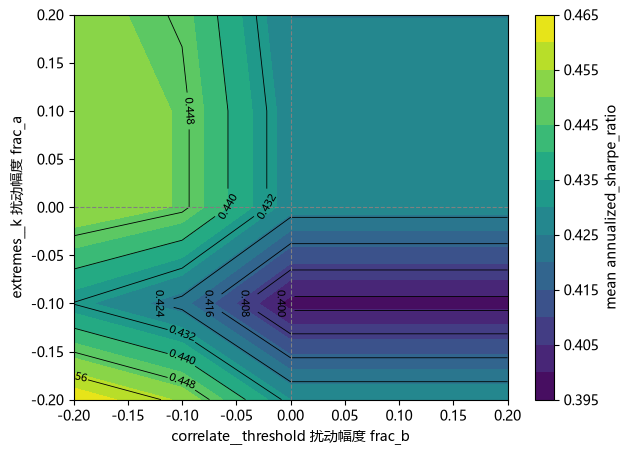

In [22]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold")
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [ ]:
frames, summary = ablate(X, folds)                # arms=None = 全部 5 臂
print(summary[["说明", "annualized_mean_mean", "annualized_sharpe_ratio_mean",
               "max_drawdown_mean", "样本数"]])

In [10]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [11]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=False)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [23]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=7 | window=1008 | inner_folds=8 | test_days=252
Fold 4: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 5: paths=7 | window=1008 | inner_folds=8 | test_days=252


In [24]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

In [ ]:
oos_mpts.plot_cumulative_returns()

In [25]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.0556 | 中位 0.0558 | 5% 0.0288 | 95% 0.0814
WF真实路径: 0.0535 | 分布中 -0.13σ | 分位 43.5%


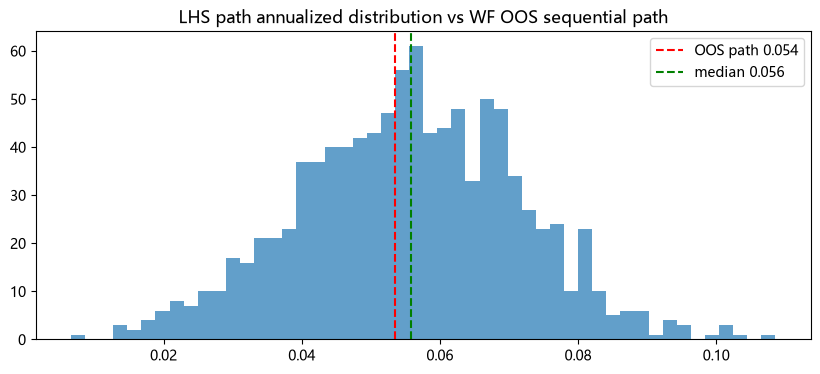

In [26]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [27]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1512 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 1.30%
  ✅ Sharpe 90% CI         : [0.100, 0.618]
  ✅ MDD median / worst-5%  : 16.57% / 21.29%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.3740
  ⚠️ PSR(0) median / 5%    : 100.00% / 99.99%


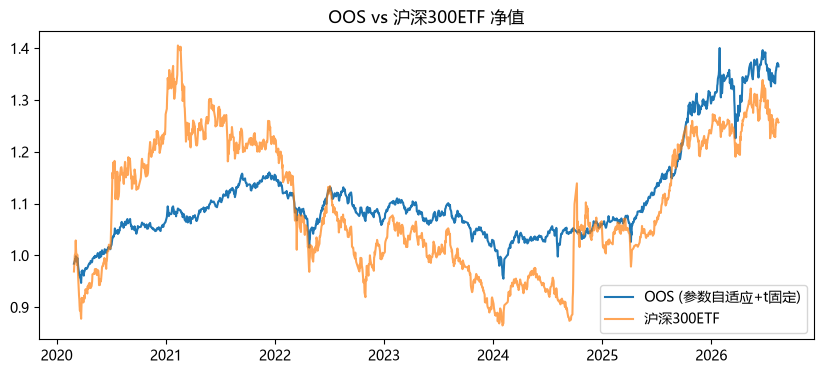

In [28]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [29]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%       -0.0167       -0.0301 -0.2311   0.5073
50%       0.0090       -0.0031 -0.0228   0.5179
95%       0.0335        0.0225  0.1678   0.5278
mean      0.0089       -0.0033 -0.0250   0.5176
